# 06 - A quality policy for training ECGs, and the 25k, 50k and 100k cohorts

Notebooks 01-05 found a small number of recordings in every source that are not usable ECGs: leads that are
missing for part or all of the recording, amplifiers saturated at their limit, and recordings that are
mostly noise. This notebook turns those findings into one policy, applies it to every training candidate,
and describes the three nested training cohorts built from the records that pass.

The policy lives in `ecg_experiment/ecg_quality.py` and the cohorts are built by
`scripts.data.build_clean_cohorts`. It only looks at the waveform, never at a diagnosis, and is applied only
to training candidates: PTB-XL validation and test records keep their difficult cases.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ecg_experiment.clean_cohorts import read_signal
from ecg_experiment.ecg_quality import EXCLUSION_REASONS, REVIEW_FLAGS
from ecg_experiment.eda.cohorts import SIZES, cohort_manifest, load_receipt, quality_rows
from ecg_experiment.eda.signals import plot_ecg
from ecg_experiment.sampled_training_dataset import SampledTrainingECGDataset

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 100})

receipt = load_receipt()
rows = quality_rows()
ORDER = ["ptbxl", "mimic", "georgia", "cpsc_2018", "cpsc_2018_extra", "chapman_shaoxing"]

## 1. The rules

Each rule targets a problem seen in the EDA. Exclusion rules remove the record; review flags are recorded
but never remove anything, because the EDA showed they are often genuine (for example, one MIMIC cart
stores limb leads that do not satisfy Einthoven's law exactly, and large QRS complexes exist in
hypertrophy).

| Rule | Type | Definition | Evidence from the EDA |
| --- | --- | --- | --- |
| `nonfinite` | exclude | any NaN or infinite sample | MIMIC stores gaps as NaN (1.3% of records) |
| `constant_lead` | exclude | a lead with the same value for all 10 s | 0.1-0.3% of records in every source except PTB-XL |
| `flat_segment` | exclude | a lead constant for at least 1 s | signal dropouts; 0.6% of CPSC records |
| `adc_rail` | exclude | any sample with absolute value of at least 32.6 mV | CPSC saturates at the 16-bit limit, also just below 32.767 mV |
| `extreme_amplitude` | exclude | peak above 20 mV but below the rail | electrode artifacts; no physiological ECG reaches this |
| `near_flat_record` | exclude | median lead standard deviation below 0.02 mV | no visible ECG in most leads |
| `noise_dominated` | exclude | more than half the median lead power in 40-150 Hz | muscle or electrode noise instead of ECG |
| `amplitude_over_10mv` | review | peak above 10 mV | the historical review flag; includes genuine large QRS |
| `limb_identity_violated` | review | largest II - I - III residual above 0.05 mV | stored limb leads not derived from each other |
| `strong_baseline_wander` | review | more than 80% of the median lead power below 0.7 Hz | baseline drift; common in Georgia |

## 2. What the rules remove, per source

The candidates are the records behind the earlier 100k cohort: the verified 500 Hz training union
(PTB-XL, part of MIMIC, Georgia, CPSC 2018 and CPSC-Extra), the ten-second Chapman view, and every record
accepted by the MIMIC 200k audit, after removing exact waveform copies. Every waveform was read and its
SHA-256 checked against the manifest before scoring.

In [3]:
rows["group"] = np.where(rows["labeled"], "ptbxl (labeled)", rows["source"])
groups = ["ptbxl (labeled)", *ORDER]
summary = rows.groupby("group").agg(records=("record_id", "size"), excluded=("excluded", "sum"))
summary["excluded %"] = 100 * summary["excluded"] / summary["records"]
by_reason = rows.groupby("group")[list(EXCLUSION_REASONS)].sum()
display(summary.join(by_reason).reindex(groups).round(3))

,records,excluded,excluded %,nonfinite,constant_lead,flat_segment,adc_rail,extreme_amplitude,near_flat_record,noise_dominated
group,,,,,,,,,,
ptbxl (labeled),15359,10,0.065,0,0,1,1,8,0,0
ptbxl,2058,2,0.097,0,0,0,0,2,0,0
mimic,197207,720,0.365,0,307,550,0,145,32,67
georgia,10187,10,0.098,0,0,3,0,4,0,3
cpsc_2018,6581,43,0.653,0,0,23,23,0,0,0
cpsc_2018_extra,3021,19,0.629,0,0,13,6,0,0,0
chapman_shaoxing,10219,2,0.020,0,0,2,0,0,0,0


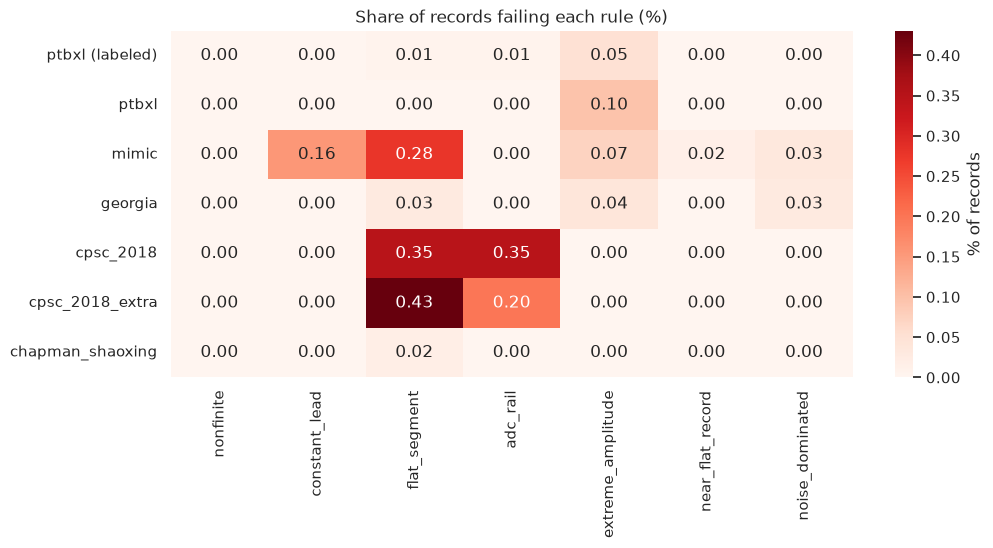

In [4]:
shares = (rows.groupby("group")[list(EXCLUSION_REASONS)].mean() * 100).reindex(groups)
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(shares, annot=True, fmt=".2f", cmap="Reds", cbar_kws={"label": "% of records"}, ax=ax)
ax.set(title="Share of records failing each rule (%)", xlabel="", ylabel="")
plt.show()

**Finding: the policy removes 806 of 244,632 records (0.33%), and where it removes them follows the EDA.**

- **MIMIC** loses 720 records (0.37%). The largest groups are leads flat for at least one second (550), of
  which 307 are constant for the whole recording, and peaks above 20 mV (145). NaN gaps do not appear here
  because the MIMIC acceptance audit already excluded them.
- **CPSC 2018 and CPSC-Extra** lose the most in relative terms (0.65% and 0.63%), all from flat segments
  and amplifier saturation. The 29 rail records are the near-rail plateaus that an exact-value rule missed.
- **Georgia, Chapman and PTB-XL** lose 0.1% or less. Only 10 of the 15,359 labeled PTB-XL training records
  fail (8 of them because one or two leads peak at 26-32 mV), so the supervised label set barely changes.

## 3. Do the rules overlap?

A record can fail several rules at once. If most exclusions came from one rule, the others would add little;
the table counts how often each pair occurs together.

In [5]:
failed = rows.loc[rows["excluded"], list(EXCLUSION_REASONS)].astype(int)
co_occurrence = failed.T @ failed
display(co_occurrence)
print("Excluded records failing exactly one rule:", int((failed.sum(axis=1) == 1).sum()), "of", len(failed))

,nonfinite,constant_lead,flat_segment,adc_rail,extreme_amplitude,near_flat_record,noise_dominated
nonfinite,0,0,0,0,0,0,0
constant_lead,0,307,307,0,1,32,0
flat_segment,0,307,592,3,40,32,0
adc_rail,0,0,3,30,0,0,0
extreme_amplitude,0,1,40,0,159,0,2
near_flat_record,0,32,32,0,0,32,0
noise_dominated,0,0,0,0,2,0,70


Excluded records failing exactly one rule: 455 of 806


**Finding: the rules overlap, but each adds records.** 455 of the 806 excluded records fail exactly one rule.
Constant leads are a subset of flat segments by definition (every constant lead is also flat for a second),
and every near-flat record also has a constant lead. The other rules catch mostly different records:
saturation, extreme amplitude and noise rarely coincide.

## 4. What an excluded record looks like

One example per rule from the public sources (MIMIC is credentialed, so its waveforms are not shown). The
example is the first failing record in record-ID order, not a hand-picked one.

nonfinite: no public example
constant_lead: no public example


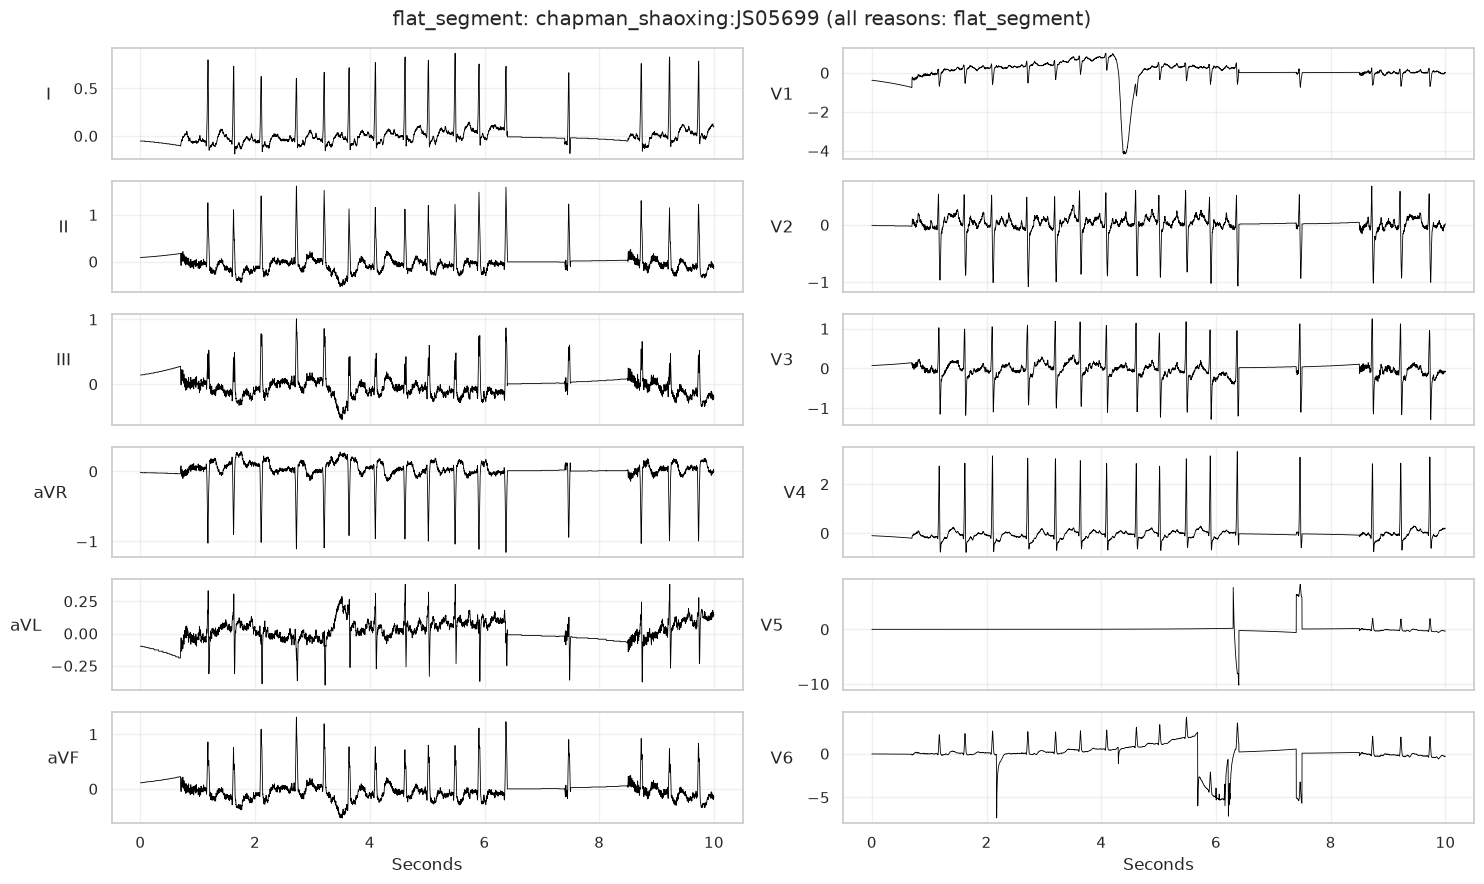

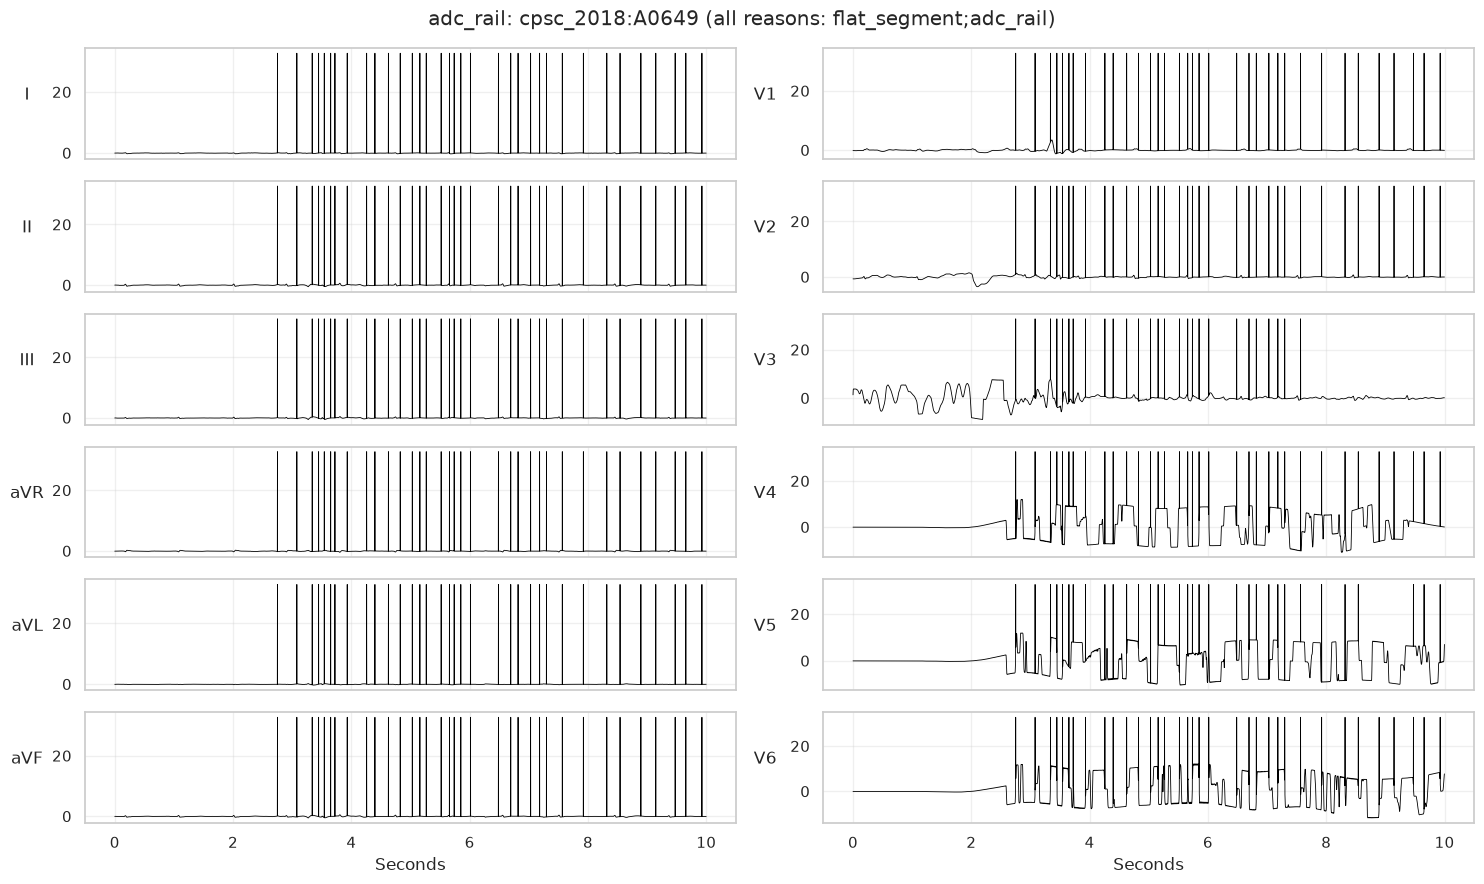

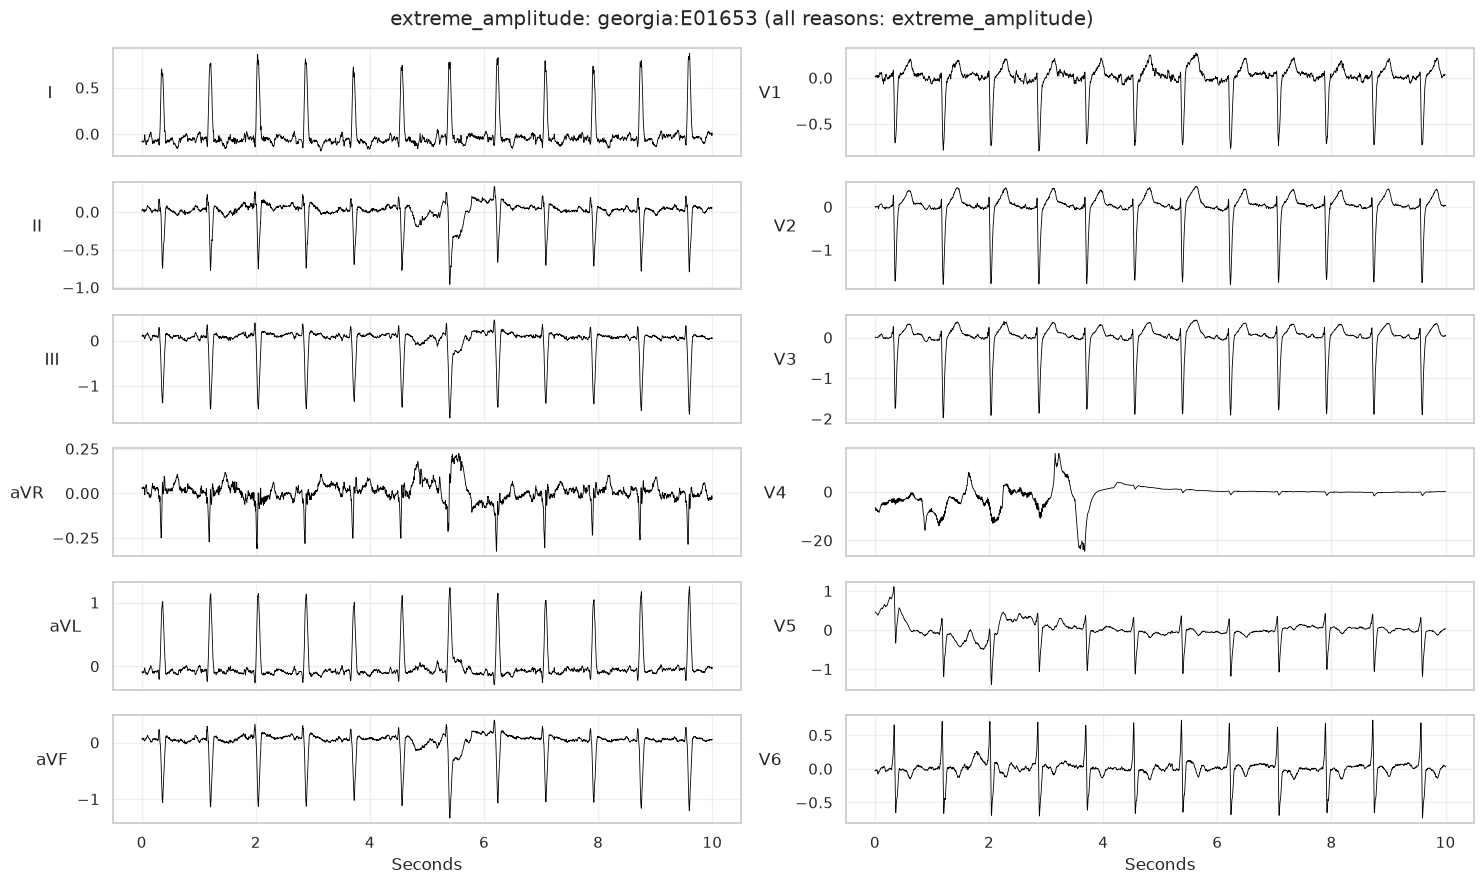

near_flat_record: no public example


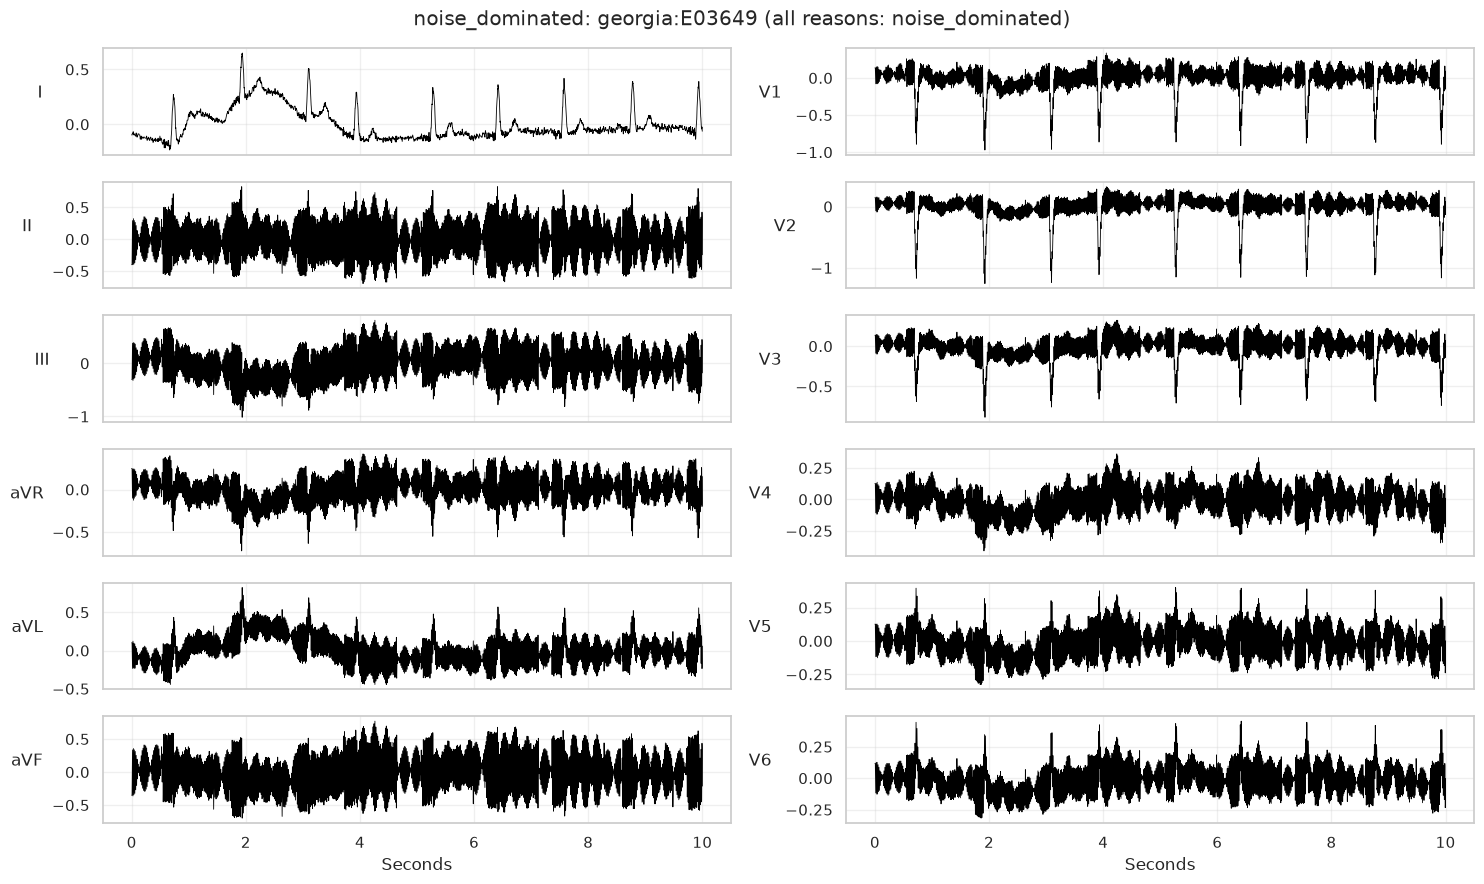

In [6]:
public = rows[(rows["source"] != "mimic") & rows["excluded"]].sort_values("record_id")
for reason in EXCLUSION_REASONS:
    examples = public[public[reason]]
    if examples.empty:
        print(f"{reason}: no public example")
        continue
    example = examples.iloc[0]
    signal = read_signal(example["backend"], example["path"], example["index"])
    plot_ecg(signal.T, 500, f"{reason}: {example['record_id']} (all reasons: {example['exclusion']})")
    plt.show()

**Finding: each example is an artifact, not an unusual heart.** The flat-segment example has every lead
drop to a straight line for about two seconds, and V5 is missing for the first six. The rail example
shows all twelve leads jumping to +32.7 mV together, the saturation pattern seen in CPSC. The
extreme-amplitude example has one lead (V4) swinging to -25 mV and then going silent, typical of an
electrode losing contact. The noise example has an ECG buried under high-frequency oscillation in eleven
leads. There are no public examples of constant leads or near-flat records, because the public views were
already curated for those.

## 5. Review flags, which are kept

Review flags mark unusual recordings that stay in the cohorts. They are useful as covariates or for later
sensitivity analyses.

In [7]:
kept = rows[~rows["excluded"]]
flags = (kept.groupby("group")[list(REVIEW_FLAGS)].mean() * 100).reindex(groups)
display(flags.round(2).rename(columns=lambda name: f"% {name}"))

,% amplitude_over_10mv,% limb_identity_violated,% strong_baseline_wander
group,,,
ptbxl (labeled),0.14,0.01,0.01
ptbxl,0.34,0.00,0.00
mimic,0.04,11.70,0.00
georgia,0.06,0.00,0.07
cpsc_2018,0.38,0.06,0.00
cpsc_2018_extra,0.40,0.00,0.00
chapman_shaoxing,0.20,0.00,0.02


**Finding: review flags are rare except one.** Peaks over 10 mV occur in 0.04-0.4% of the kept records.
The limb-identity flag marks 11.7% of MIMIC records and almost nothing elsewhere: it is the MIMIC cart that
stores limb leads independently (notebook 02). Removing those records would remove a whole device, so they
are kept.

## 6. The 25k, 50k and 100k cohorts

Each cohort has N unlabeled ECGs plus all clean labeled PTB-XL training records, which are needed for
supervised readouts. The unlabeled part uses the same rule as the earlier 100k cohort: MIMIC is capped at
70%, and the other 30% is shared among the other sources in proportion to their clean records. Each source
is shuffled once with a fixed seed and each cohort takes the first records of every source, so the 25k
cohort is inside the 50k one, which is inside the 100k one. The source mix is the same at every size;
only the amount of data changes.

,25k,50k,100k
source,,,
ptbxl,15831,16313,17277
mimic,17500,35000,70000
georgia,2386,4772,9544
cpsc_2018,1533,3066,6131
cpsc_2018_extra,704,1407,2815
chapman_shaoxing,2395,4791,9582
total,40349,65349,115349


25k inside 50k: True | 50k inside 100k: True


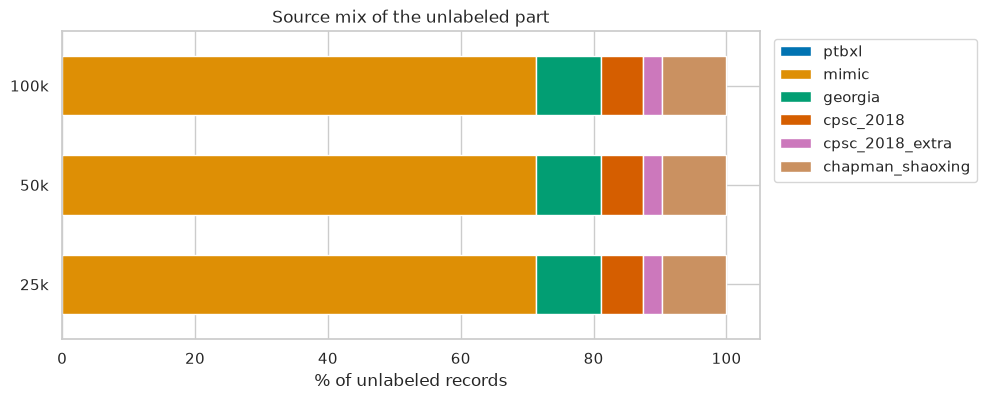

In [8]:
manifests = {size: cohort_manifest(f"clean_{size}_plus_labels_v1") for size in SIZES}
composition = pd.DataFrame({size: manifest["source"].value_counts() for size, manifest in manifests.items()})
composition.loc["total"] = composition.sum()
display(composition.reindex([*ORDER, "total"]))
ids = {size: set(manifest["record_id"]) for size, manifest in manifests.items()}
print("25k inside 50k:", ids["25k"] <= ids["50k"], "| 50k inside 100k:", ids["50k"] <= ids["100k"])
unlabeled = {size: manifest[manifest["label_scope"] == "ssl_only"]["source"].value_counts(normalize=True)
             for size, manifest in manifests.items()}
mix = pd.DataFrame(unlabeled).reindex(ORDER).fillna(0) * 100
fig, ax = plt.subplots(figsize=(9, 4))
mix.T.plot.barh(stacked=True, ax=ax, width=0.6)
ax.set(xlabel="% of unlabeled records", ylabel="", title="Source mix of the unlabeled part")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()

In [9]:
for size in SIZES:
    directory = ROOT / "data/processed" / f"clean_{size}_plus_labels_v1"
    ssl = SampledTrainingECGDataset(directory)
    full = SampledTrainingECGDataset(directory, purpose="supervised")
    limited = SampledTrainingECGDataset(directory, purpose="supervised", label_budget="0.1")
    item = ssl[len(ssl) - 1]
    print(f"{size}: {len(ssl):,} SSL records, {len(full):,} full labels, {len(limited):,} limited labels; "
          f"last record read and hash-checked ({item['source']})")

25k: 40,349 SSL records, 15,349 full labels, 1,517 limited labels; last record read and hash-checked (mimic)


50k: 65,349 SSL records, 15,349 full labels, 1,517 limited labels; last record read and hash-checked (mimic)


100k: 115,349 SSL records, 15,349 full labels, 1,517 limited labels; last record read and hash-checked (mimic)


**Finding: the three cohorts are nested, share one source mix, and load with the existing loader.**

| Cohort | Unlabeled ECGs | Labeled PTB-XL | Total |
| --- | ---: | ---: | ---: |
| `clean_25k_plus_labels_v1` | 25,000 | 15,349 | 40,349 |
| `clean_50k_plus_labels_v1` | 50,000 | 15,349 | 65,349 |
| `clean_100k_plus_labels_v1` | 100,000 | 15,349 | 115,349 |

The unlabeled part is 70% MIMIC in all three, and the other sources keep their relative sizes. The full label
budget has 15,349 records and the limited one 1,517; one record of the fixed 1,518-label subset failed the
policy. Every record in every cohort passed the policy, and none is a PTB-XL validation or test record.

## 7. How the earlier 100k cohort compares

`sampled_100k_plus_labels_v1` was drawn from the same candidates without these rules. Counting its records
that fail the policy shows how much the policy changes in practice.

In [10]:
previous = cohort_manifest("sampled_100k_plus_labels_v1")
previous = previous.merge(rows[["record_id", "excluded", *EXCLUSION_REASONS]], on="record_id", validate="1:1")
display(previous.groupby("source").agg(records=("record_id", "size"), failing=("excluded", "sum"))
        .reindex(ORDER))
display(previous[list(EXCLUSION_REASONS)].sum().rename("records in the earlier 100k cohort"))

,records,failing
source,,
ptbxl,17284,12
mimic,70000,257
georgia,9531,10
cpsc_2018,6157,40
cpsc_2018_extra,2826,18
chapman_shaoxing,9561,2


nonfinite              0
constant_lead        114
flat_segment         244
adc_rail              27
extreme_amplitude     64
near_flat_record      17
noise_dominated       21
Name: records in the earlier 100k cohort, dtype: int64

**Finding: the earlier 100k cohort contains 339 records that fail the policy** (0.29% of 115,359): 257 MIMIC,
40 CPSC 2018, 18 CPSC-Extra, 12 PTB-XL, 10 Georgia and 2 Chapman. They include the 114 constant-lead MIMIC
records already noted in its documentation. Counting by rule, 244 have a flat segment (including those
114), 64 an extreme amplitude and 27 saturation. The fraction is small, but these records are not ECGs in the affected
leads.

## 8. Conclusions

- One waveform-only policy, with seven exclusion rules derived from the EDA, removes 0.33% of the training
  candidates. The removed records are artifacts: dropouts, saturation, electrode pops and noise.
- The removal rate follows each source's known weak points: CPSC saturation, MIMIC flat and constant leads,
  and hardly anything from PTB-XL, Georgia or Chapman.
- Flags for genuine but unusual recordings (large QRS, independent limb leads, baseline wander) are kept as
  information, not used to exclude.
- The 25k, 50k and 100k cohorts are nested, have the same source mix, and differ only in size. That makes
  them suitable for a data-scaling comparison in which only the amount of data changes.